In [38]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
import ast

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]   
TARGET_INT = ["Theta"]  
TARGET = ["DeltaTheta"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 7
TS = 0.07

In [39]:
TITLES = ["Train_1", "Train_2", "Test_1", "Test_2", "Test_3", "Val", "LSG_1", "LSG_2"]

Datasets = []
NormDatasets = []

# Ler Datasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    Datasets.append(df)

# Ler NormDatasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/NormDatasets.xlsx", sheet_name=title)
    NormDatasets.append(df)
    
OUT_SCALER = joblib.load("./scalers/out_scaler.pkl")

In [40]:
results = pd.read_excel("resultados.xlsx")
results.head()

,model,Neurons,Ld,Lp,reg,seed,R2_Train_1_Theta,MSE_Train_1_Theta,R2_Train_2_Theta,MSE_Train_2_Theta,R2_Val_Theta,MSE_Val_Theta,R2_Test_1_Theta,MSE_Test_1_Theta,R2_Test_2_Theta,MSE_Test_2_Theta,R2_Test_3_Theta,MSE_Test_3_Theta
0,model_arch16_r0.01_seed4657,[16],0.3,0.7,0.01,4657,0.767395,0.053156,0.775335,0.050937,0.549647,0.147388,0.795756,0.046980,0.875209,0.029395,0.611454,0.127768
1,model_arch16_r0.01_seed1637,[16],0.3,0.7,0.01,1637,0.716742,0.064731,0.300872,0.158510,-3.058264,1.328157,0.495367,0.116075,0.795508,0.048168,0.613646,0.127047
2,model_arch16_r0.01_seed9830,[16],0.3,0.7,0.01,9830,0.836599,0.037341,0.747873,0.057163,-4.216472,1.707207,0.805612,0.044713,0.869874,0.030651,0.100943,0.295643
3,model_arch16_r0.01_seed2734,[16],0.3,0.7,0.01,2734,0.783620,0.049448,0.454758,0.123620,-5.338654,2.074466,0.567381,0.099511,0.845270,0.036447,0.383038,0.202880
4,model_arch16_r0.01_seed3087,[16],0.3,0.7,0.01,3087,0.788302,0.048378,0.623237,0.085422,-3.194830,1.372852,0.626403,0.085935,0.884114,0.027297,0.608381,0.128779


In [41]:
def PickModels(df, target, tr1=0.0, tr2=0.0, v1=0.0, t3=0.0):

    r2_tr1 = f"R2_Train_1_{target}"
    r2_tr2 = f"R2_Train_2_{target}"
    r2_val = f"R2_Val_{target}"
    r2_t3 = f"R2_Test_3_{target}"

    # filtro mínimo
    filtered = df[
        (df[r2_tr1] > tr1) &
        (df[r2_tr2] > tr2) &
        (df[r2_t3] > t3) &
        (df[r2_val] > v1)
    ]

    if filtered.empty:
        print("Nenhum modelo satisfaz os critérios.")
        return None

    # 🔹 melhor para cada métrica
    best_tr1 = filtered.sort_values(r2_tr1, ascending=False).iloc[0]
    best_tr2 = filtered.sort_values(r2_tr2, ascending=False).iloc[0]
    best_val = filtered.sort_values(r2_val, ascending=False).iloc[0]
    best_t3 = filtered.sort_values(r2_t3, ascending=False).iloc[0]

    selected = pd.DataFrame([best_tr1, best_tr2, best_val, best_t3]).drop_duplicates()

    cols = ["model", "Neurons", "reg",  r2_tr1, r2_tr2, r2_val, r2_t3]

    table = selected[cols].copy()

    # 🔹 calcular média das métricas
    mean_values = table[[r2_tr1, r2_tr2, r2_val, r2_t3]].mean()

    mean_row = pd.DataFrame([{
        "model": "MEAN",
        "Neurons": "-",
        "reg": "-",
        r2_tr1: mean_values[r2_tr1],
        r2_tr2: mean_values[r2_tr2],
        r2_val: mean_values[r2_val],
        r2_t3: mean_values[r2_t3]
    }])

    table_mean = pd.concat([table, mean_row], ignore_index=True)

    display(table_mean)

    return selected

In [42]:
def BuildModel(architecture, r):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)))
    regularizer =  tf.keras.regularizers.l2(r)
        
    for i, units in enumerate(architecture):

        if i < len(architecture) - 1:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    return_sequences=True,
                    kernel_regularizer=regularizer,
                    recurrent_regularizer=regularizer,
                    bias_regularizer=regularizer
            ))
        else:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    kernel_regularizer=regularizer,
                    recurrent_regularizer=regularizer,
                    bias_regularizer=regularizer
                )
            )

    model.add(tf.keras.layers.Dense(OUTPUT_SIZE,
                                    activation='linear',
                                    kernel_regularizer=regularizer,
                                    bias_regularizer=regularizer))

    return model

In [43]:
def LoadModelFromRow(row):

    # arquitetura
    arch = row["Neurons"]
    if isinstance(arch, str):
        arch = ast.literal_eval(arch)

    r = float(row["reg"])
    model_name = row["model"]

    weights_path = f"weights/{model_name}.weights.h5"
    print(f"{arch} - {r}")
    # build
    model = BuildModel(arch, r)
    model.build((None, TIME_STEPS, INPUT_SIZE))

    # load pesos
    model.load_weights(weights_path)

    return model

In [44]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)


In [45]:
R = tf.constant(0.0341, dtype=tf.float32)
L = tf.constant(0.0606, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    dtheta_cin = (R / (2 * L)) * (Wd - We)
    # dx_cin = (R / 2) * tf.cos(theta) * (Wd + We)
    # dy_cin = (R / 2) * tf.sin(theta) * (Wd + We)

    # return [dtheta_cin, dx_cin, dy_cin]
    return [dtheta_cin]


def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T

In [46]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, color='tab:blue', label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, color='tab:orange', label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=2, color='tab:green', label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)
    fig, axs = plt.subplots(n_datasets, n_targets, figsize=(6 * n_targets, 4 * n_datasets))
    

    # estrutura das métricas
    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val": [],
            "R2_Test_1": [], "R2_Test_2": [], "R2_Test_3": [],
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val": [],
            "MSE_Test_1": [], "MSE_Test_2": [], "MSE_Test_3": [],
            "MSE_LSG_1": [], "MSE_LSG_2": [],

        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS] # Normalizado
        y = Datasets[i][TARGET_INT] # Real

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição da rede
        pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalização
        y_pred_diff = OUT_SCALER.inverse_transform(pred)

        # arrays reconstruídos
        y_true = y
        y_pred = np.zeros_like(y_pred_diff)
        y_cin = GetCin(Datasets[i])
        
        y_cin = y_cin[:y_true.shape[0]]

        # valores iniciais reais
        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        # reconstrução por integração cumulativa
        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(y_pred_diff[:, j] * TS)

        # cálculo das métricas
        for j, name in enumerate(TARGET_INT):

            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> " f"R² = {r2:.4f}, MSE = {mse:.4e}")

            # Seleciona o eixo correto (funciona mesmo com 1x1, 1x2 ou 3x2)
            ax = axs[i][j] if n_datasets > 1 and n_targets > 1 else (
                axs[j] if n_targets > 1 else axs[i] if n_datasets > 1 else axs
            )
            PlotOut(ax, TITLES[i], name, y_true[:, j], y_pred[:, j], y_cin)

    plt.tight_layout()


    return metrics

In [47]:
rows = PickModels(results, "Theta", tr1=0.6, tr2=0.6, v1=0.6, t3=0.6)

,model,Neurons,reg,R2_Train_1_Theta,R2_Train_2_Theta,R2_Val_Theta,R2_Test_3_Theta
0,model_arch16-8-4_r0.01_seed4657,"[16, 8, 4]",0.01,0.913422,0.706198,0.679538,0.695625
1,model_arch32-16-8_r0.01_seed9830,"[32, 16, 8]",0.01,0.691523,0.716527,0.719282,0.705938
2,MEAN,-,-,0.802472,0.711363,0.699410,0.700781


In [ ]:
best_idx = results["R2_Val_Theta"].idxmax()
row1 = results.loc[best_idx] # funciona     model_arch16-8-4_r0.9_seed4657
row2 = rows.iloc[0]          # não funciona model_arch16-8-4_r0.01_seed4657

model2 = LoadModelFromRow(row2)
model2.summary()
model1 = LoadModelFromRow(row1)
model1.summary()

[16, 8, 4] - 0.01
Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_51 (SimpleRNN)   (None, 7, 16)             336       
                                                                 
 simple_rnn_52 (SimpleRNN)   (None, 7, 8)              200       
                                                                 
 simple_rnn_53 (SimpleRNN)   (None, 4)                 52        
                                                                 
 dense_17 (Dense)            (None, 1)                 5         
                                                                 
Total params: 593 (2.32 KB)
Trainable params: 593 (2.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
[16, 8, 4] - 0.9
Model: "sequential_18"
_________________________________________________________________
 Layer (type)                Ou

Theta | Train_1 -> R² = 0.9154, MSE = 1.9335e-02
Theta | Train_2 -> R² = 0.4628, MSE = 1.2180e-01
Theta | Test_1 -> R² = 0.7864, MSE = 4.9133e-02
Theta | Test_2 -> R² = 0.8219, MSE = 4.1946e-02
Theta | Test_3 -> R² = -1.3391, MSE = 7.6919e-01
Theta | Val -> R² = 0.7337, MSE = 8.7157e-02
Theta | LSG_1 -> R² = 0.3959, MSE = 2.4815e-01
Theta | LSG_2 -> R² = -0.0825, MSE = 3.7098e-01


model                model_arch16-8-4_r0.9_seed4657
Neurons                                  [16, 8, 4]
Ld                                              0.7
Lp                                              0.3
reg                                             0.9
seed                                           4657
R2_Train_1_Theta                           0.915392
MSE_Train_1_Theta                          0.019335
R2_Train_2_Theta                           0.462802
MSE_Train_2_Theta                          0.121796
R2_Val_Theta                               0.733686
MSE_Val_Theta                              0.087157
R2_Test_1_Theta                            0.786395
MSE_Test_1_Theta                           0.049133
R2_Test_2_Theta                            0.821924
MSE_Test_2_Theta                           0.041946
R2_Test_3_Theta                           -1.339117
MSE_Test_3_Theta                           0.769189
Name: 235, dtype: object

Theta | Train_1 -> R² = 0.6963, MSE = 6.9405e-02
Theta | Train_2 -> R² = 0.7528, MSE = 5.6042e-02
Theta | Test_1 -> R² = 0.3558, MSE = 1.4819e-01
Theta | Test_2 -> R² = 0.8409, MSE = 3.7476e-02
Theta | Test_3 -> R² = 0.3832, MSE = 2.0283e-01
Theta | Val -> R² = -3.3004, MSE = 1.4074e+00
Theta | LSG_1 -> R² = 0.3717, MSE = 2.5809e-01
Theta | LSG_2 -> R² = -2.5222, MSE = 1.2071e+00


model                model_arch16-8-4_r0.01_seed4657
Neurons                                   [16, 8, 4]
Ld                                               0.3
Lp                                               0.7
reg                                             0.01
seed                                            4657
R2_Train_1_Theta                            0.913422
MSE_Train_1_Theta                           0.019785
R2_Train_2_Theta                            0.706198
MSE_Train_2_Theta                           0.066612
R2_Val_Theta                                0.679538
MSE_Val_Theta                               0.104878
R2_Test_1_Theta                             0.934632
MSE_Test_1_Theta                            0.015036
R2_Test_2_Theta                             0.826228
MSE_Test_2_Theta                            0.040932
R2_Test_3_Theta                             0.695625
MSE_Test_3_Theta                             0.10009
Name: 220, dtype: object

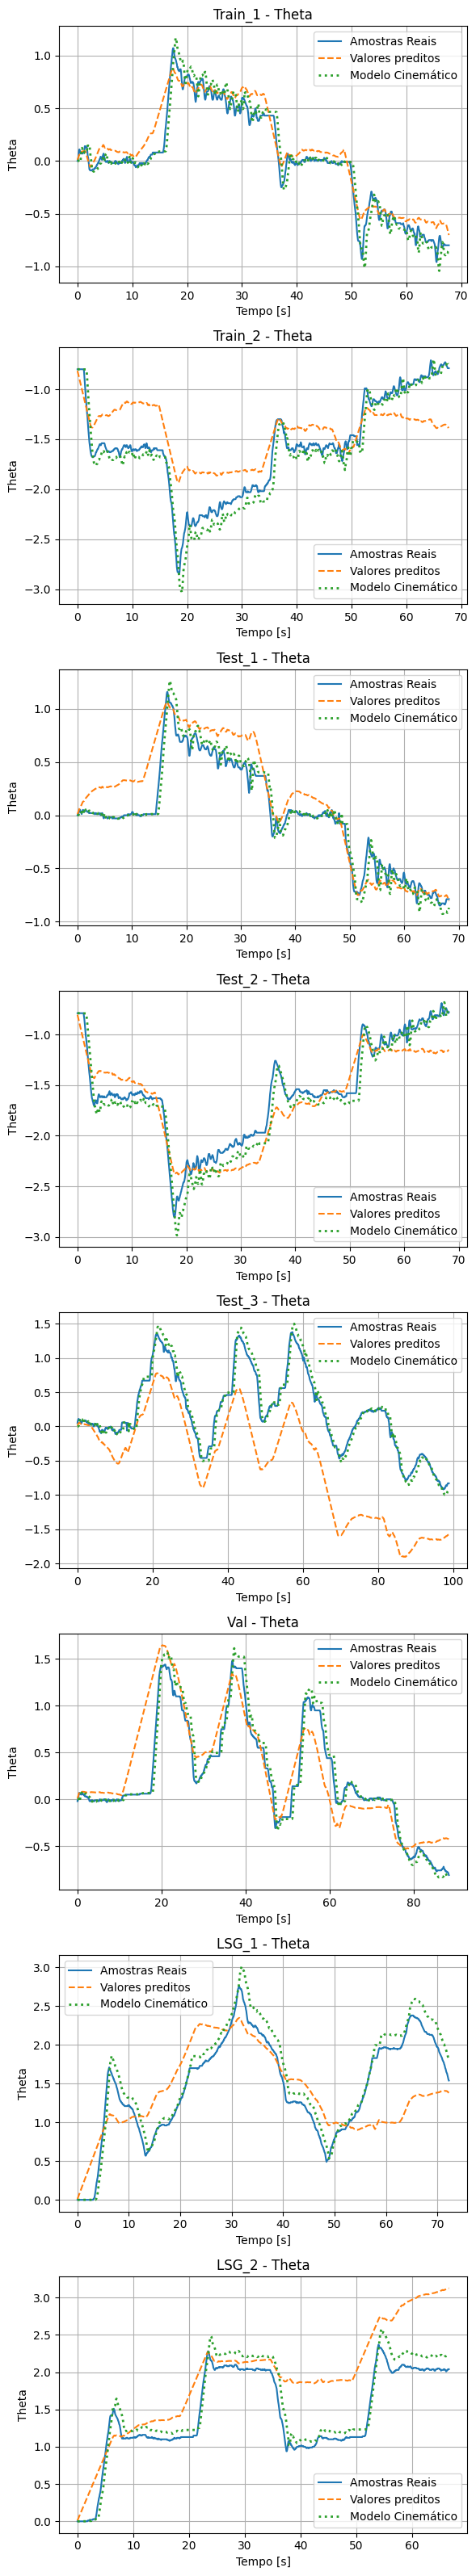

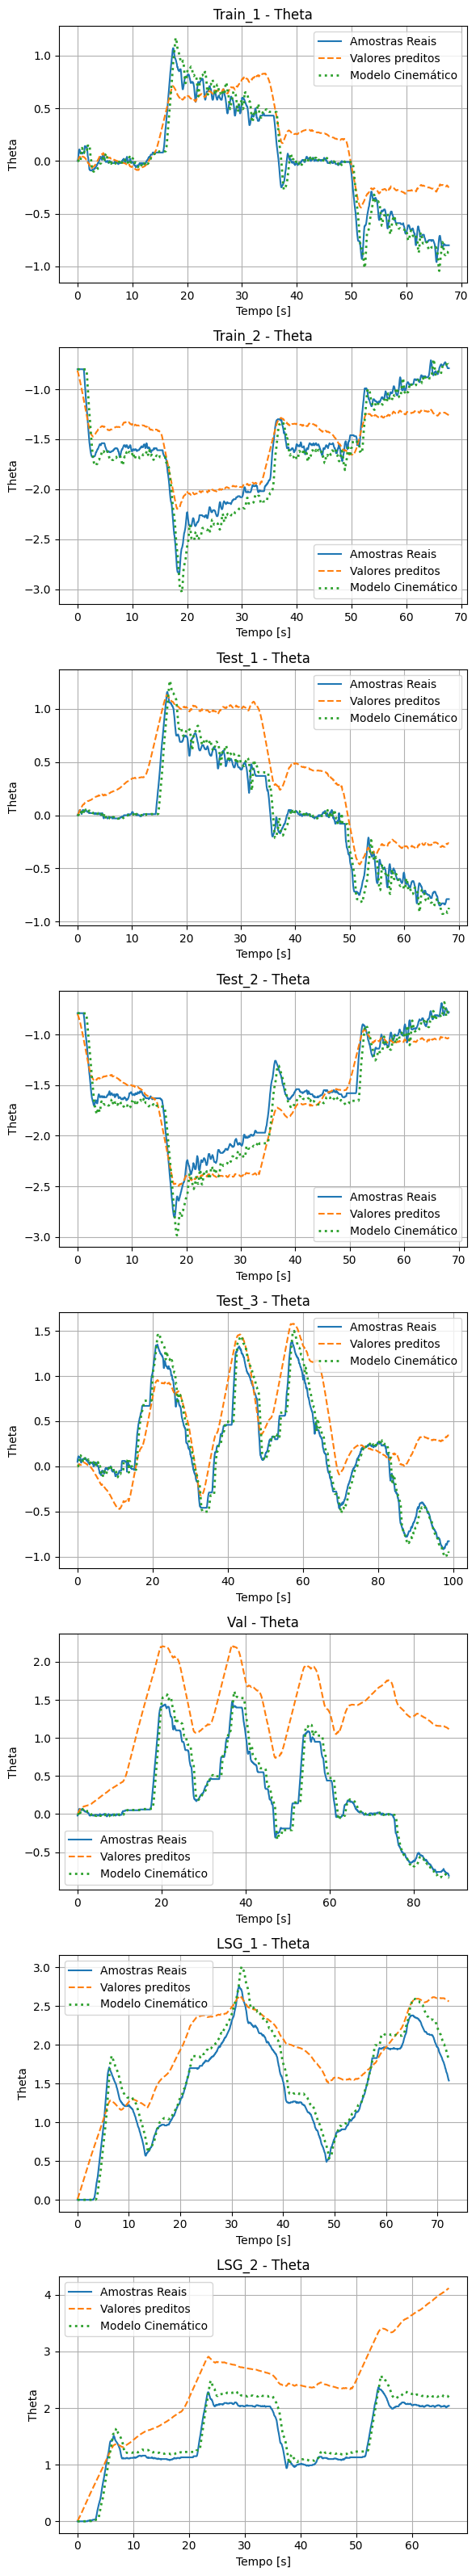

In [49]:
metrics1 = EvalModel(model1)
display(row1)
metrics2 = EvalModel(model2)
display(row2)
